In [ ]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [ ]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)

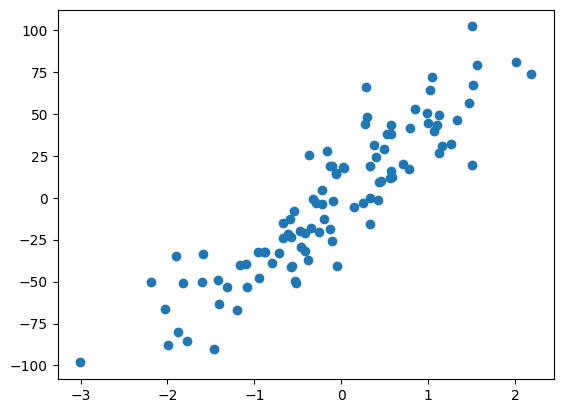

In [ ]:
plt.scatter(X,y)

In [ ]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
lr = LinearRegression()
lr.fit(X,y)

LinearRegression()

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[38.53595716]
2.266616688430404


In [ ]:
from sklearn.metrics import r2_score
y_pred = lr.predict(X_test)

r2_score(y_test,y_pred)

0.8744439226881422

In [ ]:
m = 70.95585748

In [ ]:
np.mean(cross_val_score(lr,X,y,scoring='r2',cv=10))

np.float64(0.7498046266017242)

In [ ]:
class GD:
  def __init__(self,learning_rate,epochs):
    self.m = 100
    self.b = -120
    self.lr = learning_rate
    self.epochs =epochs

  def fit(self,X,y):
    #calculate the b using GD
    for i in range(self.epochs):
      loss_slope_wrt_m = -2 *np.sum((y-self.m*X.ravel() -self.m)*X.ravel())
      loss_slope_wrt_b = -2 *np.sum(y-self.m*X.ravel() -self.b)
      self.b = self.b -(self.lr *loss_slope_wrt_b)
      self.m = self.m -(self.lr *loss_slope_wrt_m)
    print(self.m,self.b)

  def predict(self,X):
    return self.m *X +self.b

In [ ]:
gd = GD(0.001,100)

In [ ]:
gd.fit(X_train,y_train)

44.50522262761593 2.584224331670674


In [ ]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.8744439226881422